# Warp Pattern

## Match Correspondence

Use this notebook as a pre-development environment check.

In [1]:
import os
from pathlib import Path

import numpy as np
import torch
import torch.nn.functional as F
import torchvision.transforms.functional as TF

import matplotlib.pyplot as plt
from matplotlib.patches import ConnectionPatch
from sklearn.decomposition import PCA
from tqdm import tqdm

from PIL import Image
import json

from origami_texturing.paths import EXTERNAL_DIR, OUTPUT_DIR, RAW_DATA_DIR, PROCESSED_DATA_DIR

target_wingup_path = RAW_DATA_DIR / "dove-wingup-target.png"
target_wingdown_path = RAW_DATA_DIR / "dove-wingdown-target.png"
generated_wingup_path = PROCESSED_DATA_DIR / "generated-wingup.png"
generated_wingdown_path = PROCESSED_DATA_DIR / "generated-wingdwon.png"

topology_wingup_path = RAW_DATA_DIR / "dove-wingup-topology.json"
topology_wingdown_path = RAW_DATA_DIR / "dove-wingdown-topology.json"

warped_wingpup_path = PROCESSED_DATA_DIR / "warped-wingup.png"
warped_wingdown_path = PROCESSED_DATA_DIR / "warped-wingdown.png"

In [2]:
DINOV3_LOCAL_LOCATION = EXTERNAL_DIR / "dinov3"
DINOV3_GITHUB_LOCATION = "facebookresearch/dinov3"

if os.getenv("DINOV3_LOCATION") is not None:
    DINOV3_LOCATION = os.getenv("DINOV3_LOCATION")
elif DINOV3_LOCAL_LOCATION.exists():
    DINOV3_LOCATION = str(DINOV3_LOCAL_LOCATION)
else:
    DINOV3_LOCATION = DINOV3_GITHUB_LOCATION

print(f"DINOv3 location set to {DINOV3_LOCATION}")

DINOv3 location set to C:\Users\morph\GitHub\origami-texturing\external\dinov3


In [3]:
# examples of available DINOv3 models:
MODEL_DINOV3_VITS = "dinov3_vits16"
MODEL_DINOV3_VITSP = "dinov3_vits16plus"
MODEL_DINOV3_VITB = "dinov3_vitb16"
MODEL_DINOV3_VITL = "dinov3_vitl16"
MODEL_DINOV3_VITHP = "dinov3_vith16plus"
MODEL_DINOV3_VIT7B = "dinov3_vit7b16"

MODEL_NAME = MODEL_DINOV3_VITHP

from origami_texturing.paths import MODELS_DIR
DINOV3_WEIGHTS_PATH = str(MODELS_DIR / "dinov3" / "dinov3_vith16plus.pth")

model = torch.hub.load(
    repo_or_dir=DINOV3_LOCATION,
    model="dinov3_vith16plus",
    source="local",
    weights=DINOV3_WEIGHTS_PATH,
)
model.cuda()

DinoVisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 1280, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (rope_embed): RopePositionEmbedding()
  (blocks): ModuleList(
    (0-31): 32 x SelfAttentionBlock(
      (norm1): LayerNorm((1280,), eps=1e-05, elementwise_affine=True)
      (attn): SelfAttention(
        (qkv): LinearKMaskedBias(in_features=1280, out_features=3840, bias=True)
        (attn_drop): Dropout(p=0.0, inplace=False)
        (proj): Linear(in_features=1280, out_features=1280, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): LayerScale()
      (norm2): LayerNorm((1280,), eps=1e-05, elementwise_affine=True)
      (mlp): SwiGLUFFN(
        (w1): Linear(in_features=1280, out_features=5120, bias=True)
        (w2): Linear(in_features=1280, out_features=5120, bias=True)
        (w3): Linear(in_features=5120, out_features=1280, bias=True)
      )
      (ls2): LayerScale()
    )
  )
  (norm): LayerNorm((

In [4]:
def load_image_item(path: Path, alpha_threshold: int = 0) -> dict[str, Image.Image | np.ndarray]:
    if not path.exists():
        raise FileNotFoundError(f"Image not found: {path}")

    rgba = Image.open(path).convert("RGBA")
    alpha = np.array(rgba.getchannel("A"))
    mask = alpha > alpha_threshold

    background = Image.new("RGBA", rgba.size, (255, 255, 255, 255))
    image = Image.alpha_composite(background, rgba).convert("RGB")
    return {"image": image, "alpha": alpha, "mask": mask}


pairs = {
    "wingup": {
        "target": load_image_item(target_wingup_path),
        "pattern": load_image_item(generated_wingup_path),
    },
    "wingdown": {
        "target": load_image_item(target_wingdown_path),
        "pattern": load_image_item(generated_wingdown_path),
    },
}

for pose_name, pair in pairs.items():
    target_size = pair["target"]["image"].size
    pattern_size = pair["pattern"]["image"].size
    print(f"{pose_name}: target={target_size}, pattern={pattern_size}")


wingup: target=(1024, 1024), pattern=(768, 1024)
wingdown: target=(1024, 1024), pattern=(768, 1024)


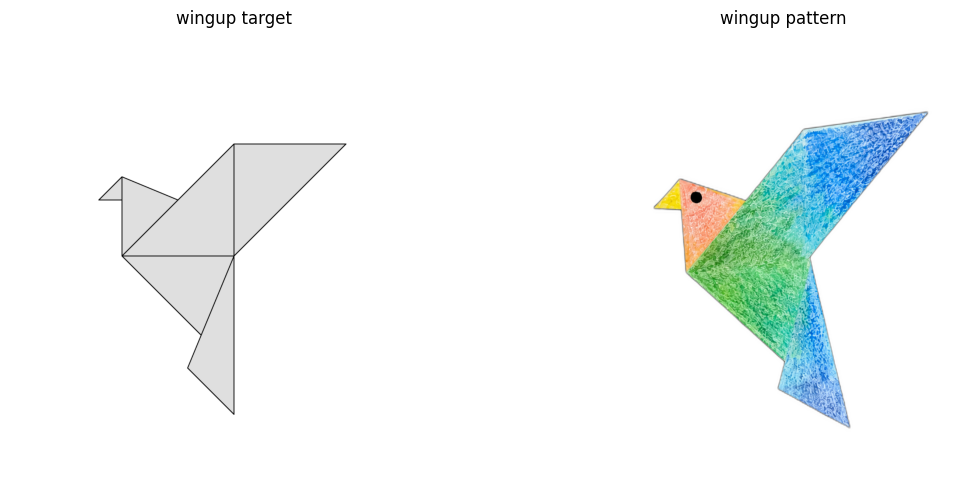

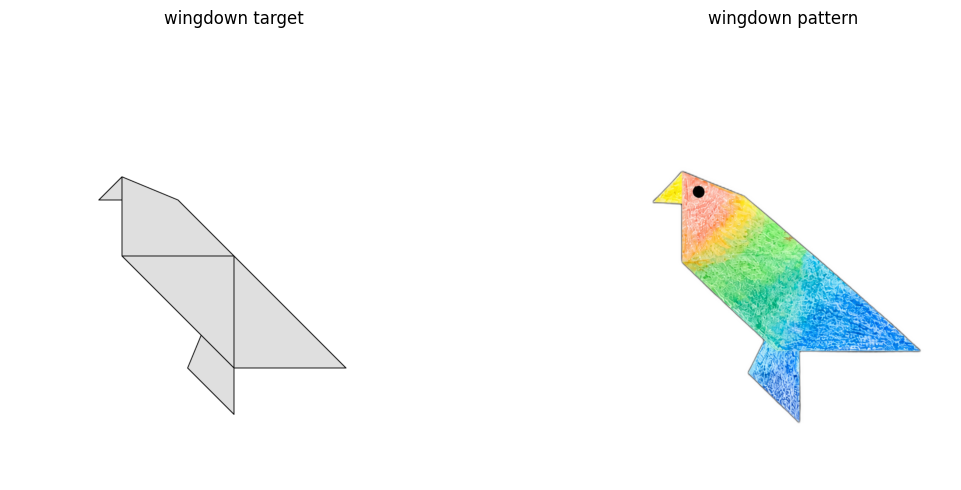

In [5]:
for pose_name in ["wingup", "wingdown"]:
    pair = pairs[pose_name]
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    for ax, image_kind in zip(axes, ["target", "pattern"]):
        ax.imshow(pair[image_kind]["image"])
        ax.set_title(f"{pose_name} {image_kind}")
        ax.axis("off")

    fig.tight_layout()
    plt.show()


In [6]:
PATCH_SIZE = 16
IMAGE_SIZE = 1024

# quantization filter for the given patch size
patch_quant_filter = torch.nn.Conv2d(1, 1, PATCH_SIZE, stride=PATCH_SIZE, bias=False)
patch_quant_filter.weight.data.fill_(1.0 / (PATCH_SIZE * PATCH_SIZE))

# image resize transform to dimensions divisible by patch size
def resize_transform(
    mask_image: Image,
    image_size: int = IMAGE_SIZE,
    patch_size: int = PATCH_SIZE,
) -> torch.Tensor:
    w, h = mask_image.size
    h_patches = int(image_size / patch_size)
    w_patches = int((w * image_size) / (h * patch_size))
    return TF.to_tensor(TF.resize(mask_image, (h_patches * patch_size, w_patches * patch_size)))

In [7]:
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

MODEL_TO_NUM_LAYERS = {
    MODEL_DINOV3_VITS: 12,
    MODEL_DINOV3_VITSP: 12,
    MODEL_DINOV3_VITB: 12,
    MODEL_DINOV3_VITL: 24,
    MODEL_DINOV3_VITHP: 32,
    MODEL_DINOV3_VIT7B: 40,
}

n_layers = MODEL_TO_NUM_LAYERS[MODEL_NAME]

pair_features = {}

with torch.inference_mode():
    with torch.autocast(device_type="cuda", dtype=torch.float32):
        for pose_name, pair in pairs.items():
            patch_mask_values = []
            patch_features = []

            for image_kind in tqdm(["target", "pattern"], desc=f"Processing {pose_name}"):
                item = pair[image_kind]

                # processing mask
                mask = Image.fromarray((item["mask"].astype(np.uint8) * 255), mode="L")
                mask_resized = resize_transform(mask)
                mask_quantized = patch_quant_filter(mask_resized).squeeze().detach().cpu()
                patch_mask_values.append(mask_quantized)

                # processing image
                image = item["image"].convert("RGB")
                image_resized = resize_transform(image)
                image_resized = TF.normalize(image_resized, mean=IMAGENET_MEAN, std=IMAGENET_STD)
                image_resized = image_resized.unsqueeze(0).cuda()

                feats = model.get_intermediate_layers(
                    image_resized,
                    n=range(n_layers),
                    reshape=True,
                    norm=True,
                )
                patch_features.append(feats[-1].squeeze().detach().cpu())

            pair_features[pose_name] = {
                "image_kinds": ["target", "pattern"],
                "patch_mask_values": patch_mask_values,
                "patch_features": patch_features,
            }


Processing wingdown: 100%|██████████| 2/2 [00:00<00:00,  2.29it/s]


In [8]:
MASK_FG_THRESHOLD = 0.5

pair_matches = {}

for pose_name, features in pair_features.items():
    patch_features = features["patch_features"]
    patch_mask_values = features["patch_mask_values"]

    patch_features[0] = F.normalize(patch_features[0], p=2, dim=0)
    patch_features[1] = F.normalize(patch_features[1], p=2, dim=0)
    dim = patch_features[0].shape[0]

    heatmaps = torch.einsum(
        "k f, f h w -> k h w",
        patch_features[0].view(dim, -1).permute(1, 0),
        patch_features[1],
    )

    # compute 2D patch locations in the target image
    n_patches_target = patch_features[0].shape[1] * patch_features[0].shape[2]
    patch_indices_target = torch.arange(n_patches_target)
    locs_2d_target = (
        torch.stack(
            (
                patch_indices_target // patch_features[0].shape[2],  # row
                patch_indices_target % patch_features[0].shape[2]    # column
            ),
            dim=-1
        ) + 0.5
    ) * PATCH_SIZE

    # compute the corresponding 2D patch locations in the pattern image
    patch_indices_pattern = torch.flatten(heatmaps, start_dim=-2).argmax(dim=-1)
    patch_match_scores = torch.flatten(heatmaps, start_dim=-2).max(dim=-1).values
    locs_2d_pattern = (
        torch.stack(
            (
                patch_indices_pattern // patch_features[1].shape[2],  # row
                patch_indices_pattern % patch_features[1].shape[2]    # column
            ),
            dim=-1
        ) + 0.5
    ) * PATCH_SIZE

    # foreground patches mask in the target image
    patches_target_fg_selection = (patch_mask_values[0].view(-1) > MASK_FG_THRESHOLD)
    # target image patches mask for patches that map to a foreground patch in the pattern image
    patches_pattern_fg_selection = (patch_mask_values[1].view(-1)[patch_indices_pattern] > MASK_FG_THRESHOLD)
    # select foreground target image patches that map to foreground pattern image patches
    patches_fg_selection = (patches_target_fg_selection * patches_pattern_fg_selection)

    # select (row, col) coordinates for the matched patches
    locs_2d_target_fg = locs_2d_target[patches_fg_selection, :]
    locs_2d_pattern_fg = locs_2d_pattern[patches_fg_selection, :]

    pair_matches[pose_name] = {
        "patch_features": patch_features,
        "patch_mask_values": patch_mask_values,
        "patch_indices_pattern": patch_indices_pattern,
        "patch_match_scores": patch_match_scores,
        "locs_2d_target": locs_2d_target,
        "locs_2d_pattern": locs_2d_pattern,
        "patches_fg_selection": patches_fg_selection,
        "locs_2d_target_fg": locs_2d_target_fg,
        "locs_2d_pattern_fg": locs_2d_pattern_fg,
        "dim": dim,
    }

    print(f"{pose_name}: matched foreground patches={locs_2d_target_fg.shape[0]}")


wingup: matched foreground patches=491
wingdown: matched foreground patches=427


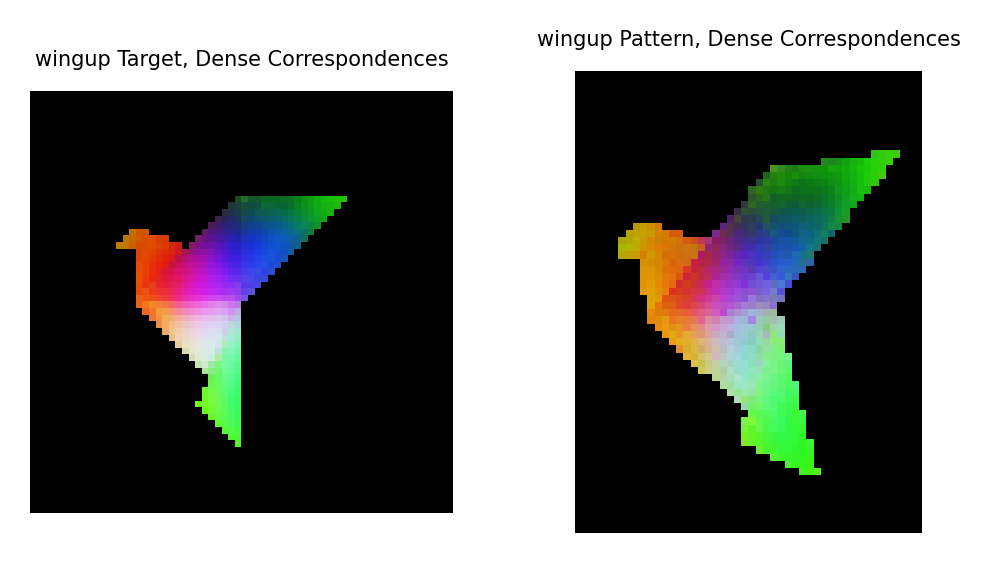

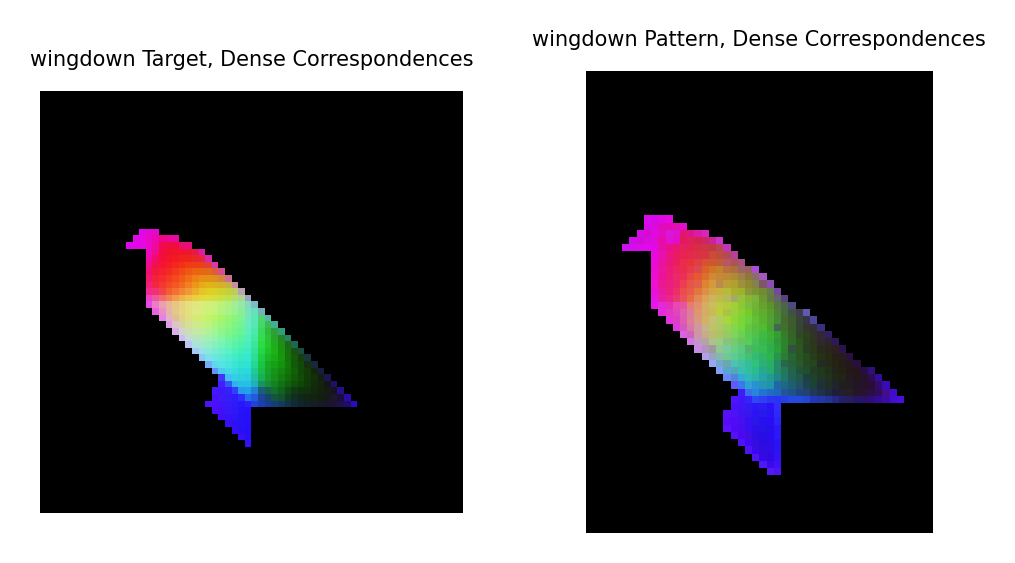

In [9]:
for pose_name, matches in pair_matches.items():
    patch_features = matches["patch_features"]
    patch_mask_values = matches["patch_mask_values"]
    patches_fg_selection = matches["patches_fg_selection"]
    dim = matches["dim"]

    pca = PCA(n_components=3, whiten=True)
    fg_patches_target = patch_features[0].view(dim, -1).permute(1, 0)[patches_fg_selection]
    pca.fit(fg_patches_target)

    # get colors for the target image
    h_patches_target = patch_features[0].shape[1]
    w_patches_target = patch_features[0].shape[2]
    x_target = patch_features[0].view(dim, -1).permute(1, 0)
    projected_image_target = torch.from_numpy(
        pca.transform(x_target.numpy())
    ).view(h_patches_target, w_patches_target, 3)
    # multiply by 2.0 and pass through a sigmoid to get vibrant colors
    projected_image_target = torch.nn.functional.sigmoid(projected_image_target.mul(2.0)).permute(2, 0, 1)

    # get colors for the pattern image
    h_patches_pattern = patch_features[1].shape[1]
    w_patches_pattern = patch_features[1].shape[2]
    x_pattern = patch_features[1].view(dim, -1).permute(1, 0)
    projected_image_pattern = torch.from_numpy(
        pca.transform(x_pattern.numpy())
    ).view(h_patches_pattern, w_patches_pattern, 3)
    projected_image_pattern = torch.nn.functional.sigmoid(projected_image_pattern.mul(2.0)).permute(2, 0, 1)

    # apply foreground masks to both visualizations
    projected_image_target *= (patch_mask_values[0] > MASK_FG_THRESHOLD)[None, :, :]
    projected_image_pattern *= (patch_mask_values[1] > MASK_FG_THRESHOLD)[None, :, :]

    matches["projected_image_target"] = projected_image_target
    matches["projected_image_pattern"] = projected_image_pattern

    plt.figure(figsize=(4, 2), dpi=300)
    plt.subplot(1, 2, 1)
    plt.imshow(projected_image_target.permute(1, 2, 0))
    plt.title(f"{pose_name} Target, Dense Correspondences", fontsize=5)
    plt.axis("off")
    plt.subplot(1, 2, 2)
    plt.imshow(projected_image_pattern.permute(1, 2, 0))
    plt.title(f"{pose_name} Pattern, Dense Correspondences", fontsize=5)
    plt.axis("off")
    plt.show()


In [10]:
topology_paths = {
    "wingup": topology_wingup_path,
    "wingdown": topology_wingdown_path,
}
SIMILARITY_TEMPERATURE = 0.1
VERTEX_MASK_FG_THRESHOLD = 0.05
BIAS_ALPHA = 1.0


def patch_center_to_original_xy(row: int, col: int, scale: float) -> list[float]:
    return [
        float((col + 0.5) * PATCH_SIZE * scale),
        float((row + 0.5) * PATCH_SIZE * scale),
    ]


def get_neighboring_patch_indices(
    vertex_xy: list[float],
    scale: float,
    h_patches: int,
    w_patches: int,
) -> list[dict]:
    """
    Pick the four patch centers around the topology vertex:
    top_left, top_right, bottom_left, bottom_right.

    This is not distance-based nearest-k selection.
    It explicitly selects the four patch cells surrounding the vertex.
    """
    x_resized = vertex_xy[0] / scale
    y_resized = vertex_xy[1] / scale

    col_left = int(np.floor(x_resized / PATCH_SIZE - 0.5))
    row_top = int(np.floor(y_resized / PATCH_SIZE - 0.5))

    neighbors = [
        ("top_left", row_top, col_left),
        ("top_right", row_top, col_left + 1),
        ("bottom_left", row_top + 1, col_left),
        ("bottom_right", row_top + 1, col_left + 1),
    ]

    patch_indices = []
    for corner, row, col in neighbors:
        if 0 <= row < h_patches and 0 <= col < w_patches:
            patch_indices.append(
                {
                    "corner": corner,
                    "row": row,
                    "col": col,
                    "index": row * w_patches + col,
                }
            )

    return patch_indices


def weighted_pattern_vertex(
    vertex_xy: list[float],
    matches: dict,
    scale_target: float,
    scale_pattern: float,
) -> list[float] | None:
    """
    Estimate the corresponding vertex position in the pattern image.

    Algorithm:
    1. Select the four target patches surrounding the topology vertex.
    2. Remove patches outside target/pattern masks.
    3. Collect their matched pattern patch centers.
    4. Compute similarity-weighted average of target patch centers: P.
    5. Compute similarity-weighted average of pattern patch centers: Q.
    6. Measure target-side bias: vertex - P.
    7. Convert that bias into pattern image scale.
    8. Correct Q using the converted bias.

    This compensates for masked-out quadrant patches causing the average to collapse inward.
    """
    patch_mask_values = matches["patch_mask_values"]
    patch_indices_pattern = matches["patch_indices_pattern"]
    patch_match_scores = matches["patch_match_scores"]
    patch_features = matches["patch_features"]

    h_patches_target, w_patches_target = patch_features[0].shape[1:]
    h_patches_pattern, w_patches_pattern = patch_features[1].shape[1:]

    candidates = []

    for patch in get_neighboring_patch_indices(
        vertex_xy,
        scale_target,
        h_patches_target,
        w_patches_target,
    ):
        target_index = patch["index"]

        pattern_index = int(patch_indices_pattern[target_index].item())
        pattern_row = pattern_index // w_patches_pattern
        pattern_col = pattern_index % w_patches_pattern

        target_mask = float(patch_mask_values[0].view(-1)[target_index].item())
        pattern_mask = float(patch_mask_values[1].view(-1)[pattern_index].item())

        if target_mask <= VERTEX_MASK_FG_THRESHOLD or pattern_mask <= VERTEX_MASK_FG_THRESHOLD:
            continue

        target_xy = patch_center_to_original_xy(
            patch["row"],
            patch["col"],
            scale_target,
        )

        pattern_xy = patch_center_to_original_xy(
            pattern_row,
            pattern_col,
            scale_pattern,
        )

        candidates.append(
            {
                "target_xy": target_xy,
                "pattern_xy": pattern_xy,
                "similarity": float(patch_match_scores[target_index].item()),
            }
        )

    if not candidates:
        return None

    # 1. Similarity-based weights
    scores = torch.tensor(
        [candidate["similarity"] for candidate in candidates],
        dtype=torch.float32,
    )

    weights = torch.softmax(
        scores / SIMILARITY_TEMPERATURE,
        dim=0,
    ).cpu().numpy()

    # 2. Weighted center of selected target patches
    target_points = np.array(
        [candidate["target_xy"] for candidate in candidates],
        dtype=np.float64,
    )

    target_center_weighted = (target_points * weights[:, None]).sum(axis=0)

    # 3. Weighted center of matched pattern patches
    pattern_points = np.array(
        [candidate["pattern_xy"] for candidate in candidates],
        dtype=np.float64,
    )

    pattern_center_weighted = (pattern_points * weights[:, None]).sum(axis=0)

    # 4. Bias correction
    vertex_xy_np = np.array(vertex_xy, dtype=np.float64)

    # Target-side bias:
    # If selected patches are biased inward/down/right/etc. from the vertex,
    # this vector points back toward the true topology vertex.
    bias_target = vertex_xy_np - target_center_weighted

    # Convert target-image bias into pattern-image scale.
    # This assumes target and pattern share the same resized IMAGE_SIZE basis.
    scale_ratio = scale_pattern / scale_target
    bias_pattern = bias_target * scale_ratio

    pattern_xy_corrected = (
        pattern_center_weighted
        + BIAS_ALPHA * bias_pattern
    )
    return pattern_xy_corrected.round(3).tolist()


In [11]:
matched_vertices_by_pose = {}

for pose_name, matches in pair_matches.items():
    pair = pairs[pose_name]
    target_image = pair["target"]["image"]
    pattern_image = pair["pattern"]["image"]

    topology = json.loads(
        topology_paths[pose_name].read_text(encoding="utf-8")
    )

    scale_target = target_image.height / IMAGE_SIZE
    scale_pattern = pattern_image.height / IMAGE_SIZE

    matched_vertices = {}

    for vertex_name, vertex_xy in topology["vertices"].items():
        pattern_xy = weighted_pattern_vertex(
            vertex_xy,
            matches,
            scale_target,
            scale_pattern,
        )

        matched_vertices[vertex_name] = {
            "target_xy": [float(vertex_xy[0]), float(vertex_xy[1])],
            "pattern_xy": pattern_xy,
        }

    matched_vertices_by_pose[pose_name] = matched_vertices

    matched_count = sum(
        vertex["pattern_xy"] is not None
        for vertex in matched_vertices.values()
    )
    print(f"{pose_name}: computed {matched_count}/{len(matched_vertices)} matched vertices")


wingup: computed 11/11 matched vertices
wingdown: computed 11/11 matched vertices


wingup: visualizing 11/11 matched vertices


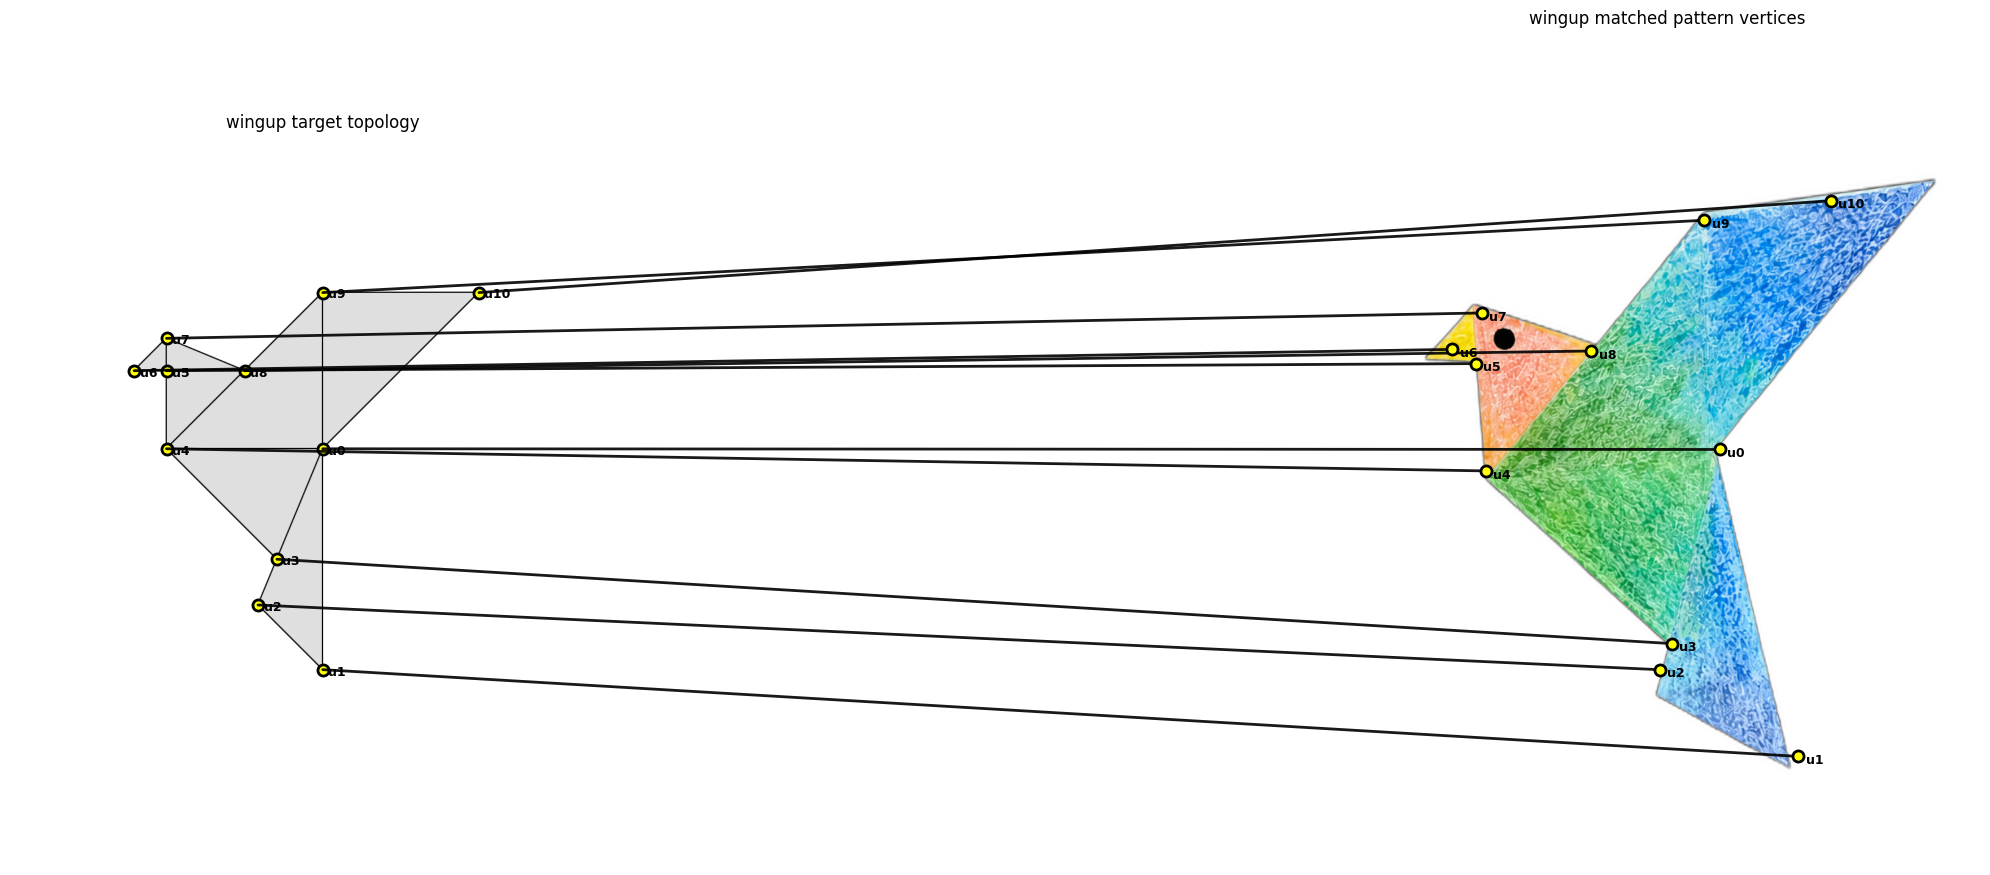

wingdown: visualizing 11/11 matched vertices


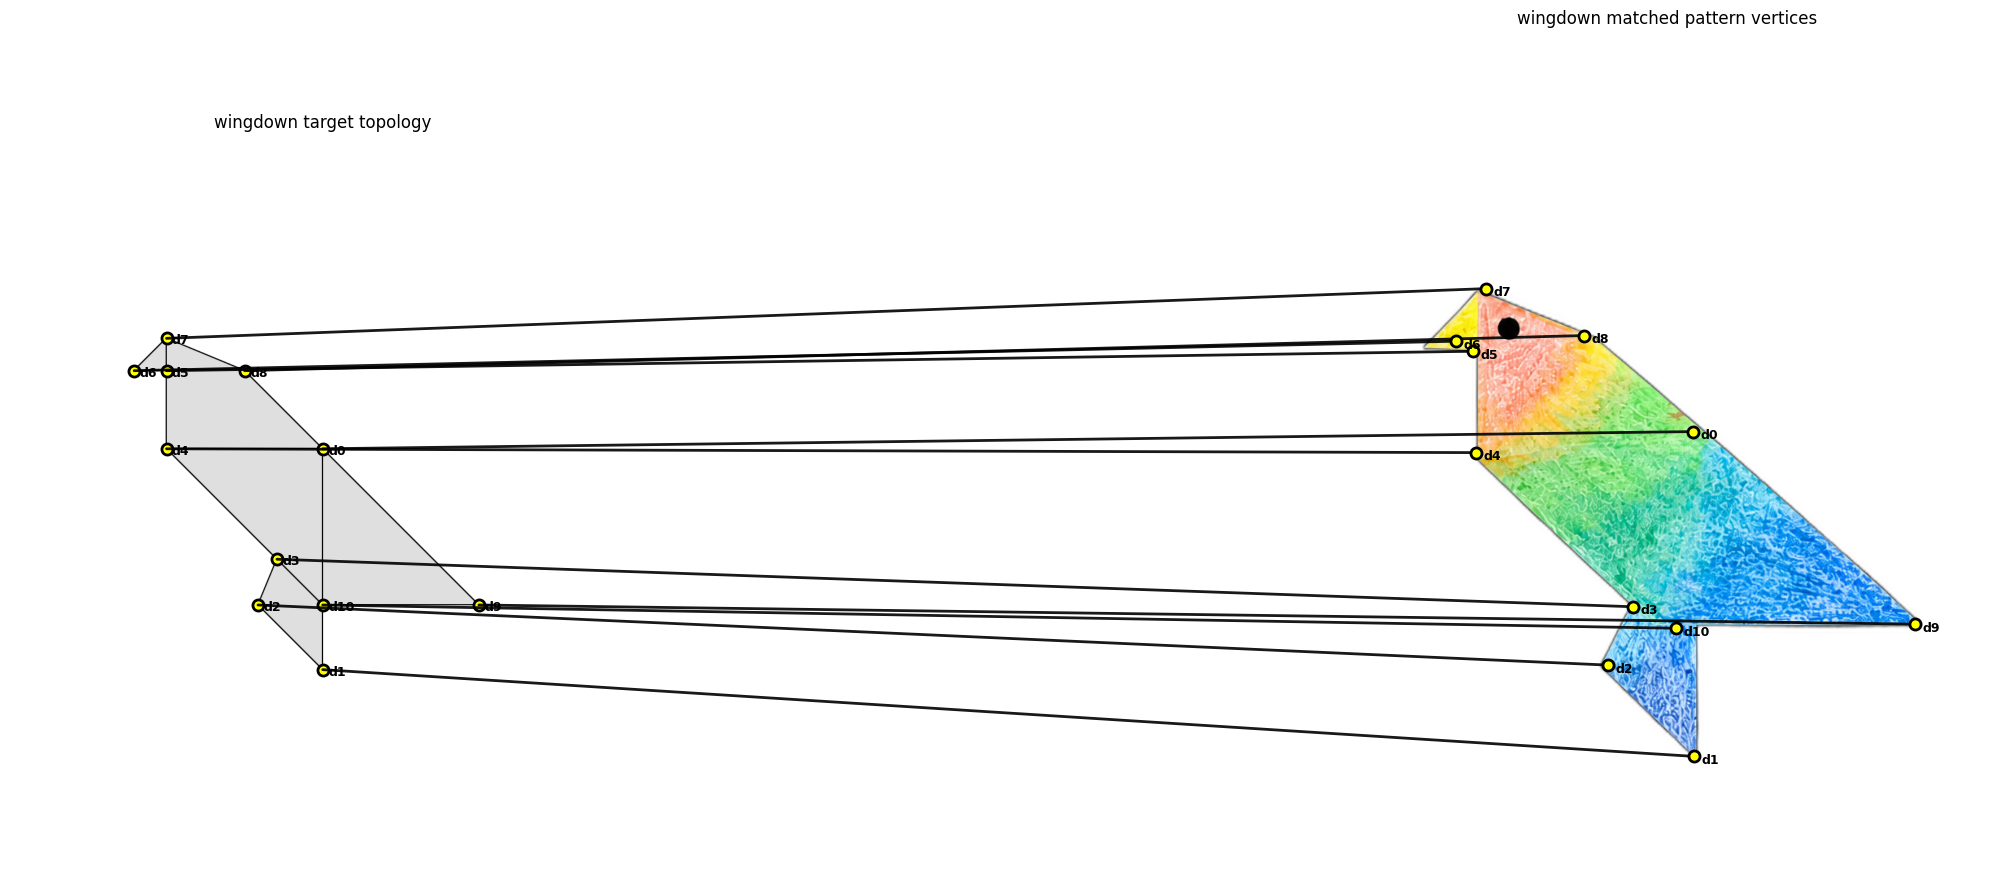

In [12]:
for pose_name, matched_vertices in matched_vertices_by_pose.items():
    pair = pairs[pose_name]
    target_image = pair["target"]["image"]
    pattern_image = pair["pattern"]["image"]
    matched_count = sum(
        vertex["pattern_xy"] is not None
        for vertex in matched_vertices.values()
    )

    print(
        f"{pose_name}: visualizing {matched_count}/{len(matched_vertices)} matched vertices"
    )

    fig = plt.figure(figsize=(20, 10))

    ax1 = fig.add_subplot(121)
    ax1.imshow(target_image)
    ax1.set_title(f"{pose_name} target topology")
    ax1.set_axis_off()

    ax2 = fig.add_subplot(122)
    ax2.imshow(pattern_image)
    ax2.set_title(f"{pose_name} matched pattern vertices")
    ax2.set_axis_off()

    for vertex_name, vertex in matched_vertices.items():
        target_x, target_y = vertex["target_xy"]

        ax1.scatter(
            target_x,
            target_y,
            s=64,
            c="yellow",
            edgecolors="black",
            linewidths=2.0,
            zorder=3,
        )

        ax1.text(
            target_x + 9,
            target_y + 9,
            vertex_name,
            color="black",
            fontsize=9,
            fontweight="bold",
            zorder=4,
        )

        if vertex["pattern_xy"] is None:
            continue

        pattern_x, pattern_y = vertex["pattern_xy"]

        ax2.scatter(
            pattern_x,
            pattern_y,
            s=64,
            c="yellow",
            edgecolors="black",
            linewidths=2.0,
            zorder=3,
        )

        ax2.text(
            pattern_x + 9,
            pattern_y + 9,
            vertex_name,
            color="black",
            fontsize=9,
            fontweight="bold",
            zorder=4,
        )

        con = ConnectionPatch(
            xyA=(target_x, target_y),
            xyB=(pattern_x, pattern_y),
            coordsA="data",
            coordsB="data",
            axesA=ax1,
            axesB=ax2,
            color="black",
            linewidth=2.0,
            alpha=0.9,
        )

        ax2.add_artist(con)

    fig.tight_layout()
    plt.show()


## Snap Points

wingup: contours=1, contour points=2043, vertices=11, mask pixels=162398, alpha threshold>0.5
[[87.0, 400.0], [145.0, 336.0], [149.0, 408.0], [160.0, 548.0], [297.0, 384.0], [371.0, 815.0], [384.0, 752.0], [432.0, 221.0], [443.0, 513.0], [530.0, 902.0], [711.0, 183.0]]


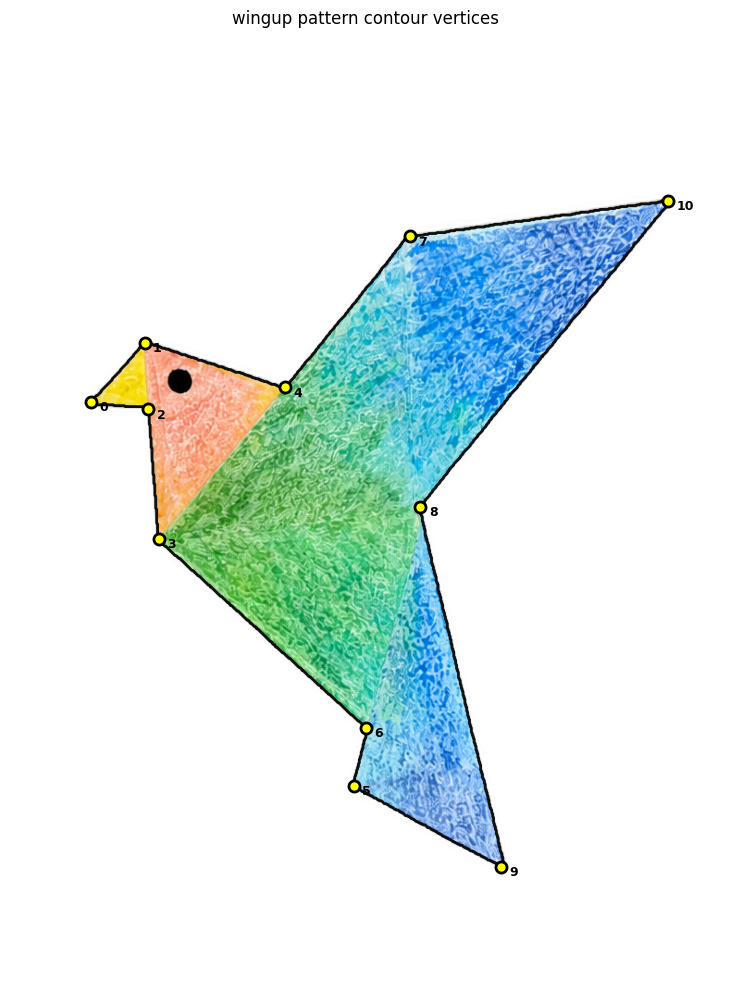

wingdown: contours=1, contour points=1647, vertices=10, mask pixels=121399, alpha threshold>0.5
[[85.0, 386.0], [149.0, 394.0], [151.0, 319.0], [151.0, 526.0], [293.0, 375.0], [302.0, 780.0], [337.0, 703.0], [414.0, 889.0], [422.0, 729.0], [694.0, 728.0]]


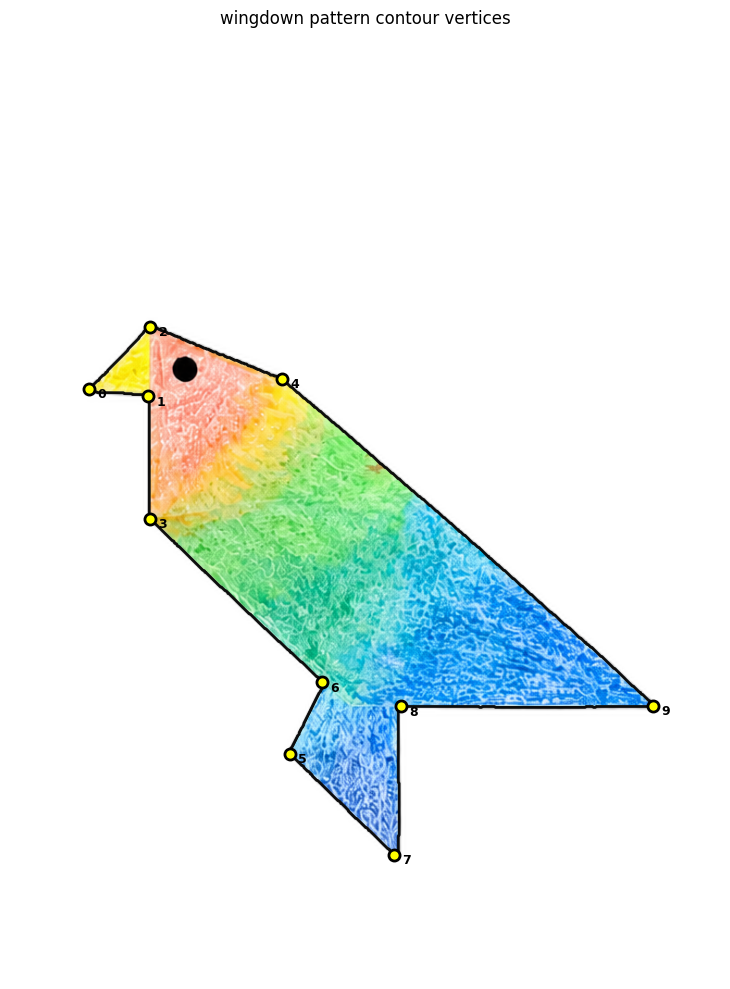

In [13]:
import cv2

CONTOUR_ALPHA_THRESHOLD = 0.5
CONTOUR_APPROXIMATION_EPSILON_RATIO = 0.012
CONTOUR_MIN_AREA = 100.0


def contour_mask_from_alpha(alpha_mask: np.ndarray | torch.Tensor) -> np.ndarray:
    if isinstance(alpha_mask, torch.Tensor):
        alpha_np = alpha_mask.detach().cpu().numpy()
    else:
        alpha_np = np.asarray(alpha_mask)

    if alpha_np.dtype == np.bool_:
        mask_np = alpha_np
    elif np.issubdtype(alpha_np.dtype, np.integer):
        mask_np = alpha_np > int(round(CONTOUR_ALPHA_THRESHOLD * 255))
    else:
        mask_np = alpha_np > CONTOUR_ALPHA_THRESHOLD

    return mask_np.astype(np.uint8) * 255


def extract_contours_xy(
    alpha_mask: np.ndarray | torch.Tensor,
    min_contour_area: float = CONTOUR_MIN_AREA,
) -> list[np.ndarray]:
    mask = contour_mask_from_alpha(alpha_mask)
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    return [
        contour.reshape(-1, 2).astype(float)
        for contour in contours
        if cv2.contourArea(contour) >= min_contour_area
    ]


def extract_contour_points_xy(
    alpha_mask: np.ndarray | torch.Tensor,
    min_contour_area: float = CONTOUR_MIN_AREA,
) -> np.ndarray:
    mask = contour_mask_from_alpha(alpha_mask)
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    contour_points = [
        contour.reshape(-1, 2).astype(float)
        for contour in contours
        if cv2.contourArea(contour) >= min_contour_area
    ]
    if not contour_points:
        return np.empty((0, 2), dtype=float)

    return np.vstack(contour_points)


def approximate_contour_vertices_xy(
    contour_xy: np.ndarray,
    approximation_epsilon_ratio: float = CONTOUR_APPROXIMATION_EPSILON_RATIO,
) -> np.ndarray:
    if len(contour_xy) == 0:
        return np.empty((0, 2), dtype=float)

    contour = contour_xy.reshape(-1, 1, 2).astype(np.float32)
    epsilon = approximation_epsilon_ratio * cv2.arcLength(contour, closed=True)
    approximated = cv2.approxPolyDP(contour, epsilon, closed=True)
    return approximated.reshape(-1, 2).astype(float)


def extract_contour_vertices_xy(
    alpha_mask: np.ndarray | torch.Tensor,
    approximation_epsilon_ratio: float = CONTOUR_APPROXIMATION_EPSILON_RATIO,
    min_contour_area: float = CONTOUR_MIN_AREA,
) -> np.ndarray:
    vertices = []
    for contour_xy in extract_contours_xy(alpha_mask, min_contour_area=min_contour_area):
        vertices.extend(
            approximate_contour_vertices_xy(
                contour_xy,
                approximation_epsilon_ratio=approximation_epsilon_ratio,
            )
        )

    if not vertices:
        return np.empty((0, 2), dtype=float)

    vertices_xy = np.array(vertices, dtype=float)
    return np.unique(np.round(vertices_xy, 2), axis=0)


pattern_contour_debug_by_pose = {}

for pose_name, pair in pairs.items():
    pattern_image = pair["pattern"]["image"]
    pattern_alpha = pair["pattern"]["alpha"]
    contour_mask = contour_mask_from_alpha(pattern_alpha)
    contours_xy = extract_contours_xy(pattern_alpha)
    contour_points_xy = extract_contour_points_xy(pattern_alpha)
    vertices_xy = extract_contour_vertices_xy(pattern_alpha)

    pattern_contour_debug_by_pose[pose_name] = {
        "mask": contour_mask,
        "contours_xy": contours_xy,
        "contour_points_xy": contour_points_xy,
        "vertices_xy": vertices_xy,
    }

    print(
        f"{pose_name}: contours={len(contours_xy)}, "
        f"contour points={len(contour_points_xy)}, "
        f"vertices={len(vertices_xy)}, "
        f"mask pixels={int((contour_mask > 0).sum())}, "
        f"alpha threshold>{CONTOUR_ALPHA_THRESHOLD}"
    )
    print(vertices_xy.tolist())

    fig, ax = plt.subplots(figsize=(8, 10))
    ax.imshow(pattern_image)

    for contour_xy in contours_xy:
        closed_contour_xy = np.vstack([contour_xy, contour_xy[0]])
        ax.plot(
            closed_contour_xy[:, 0],
            closed_contour_xy[:, 1],
            color="black",
            linewidth=2.0,
            alpha=0.9,
            zorder=2,
        )

    if len(vertices_xy) > 0:
        ax.scatter(
            vertices_xy[:, 0],
            vertices_xy[:, 1],
            s=64,
            c="yellow",
            edgecolors="black",
            linewidths=2.0,
            zorder=3,
        )

        for vertex_index, (x, y) in enumerate(vertices_xy):
            ax.text(
                x + 9,
                y + 9,
                str(vertex_index),
                color="black",
                fontsize=9,
                fontweight="bold",
                zorder=4,
            )

    ax.set_title(f"{pose_name} pattern contour vertices")
    ax.set_axis_off()
    fig.tight_layout()
    plt.show()


wingup: snapped 11/11 matched pattern vertices (11 to vertices, 0 to contour fallback) using 11 contour vertices


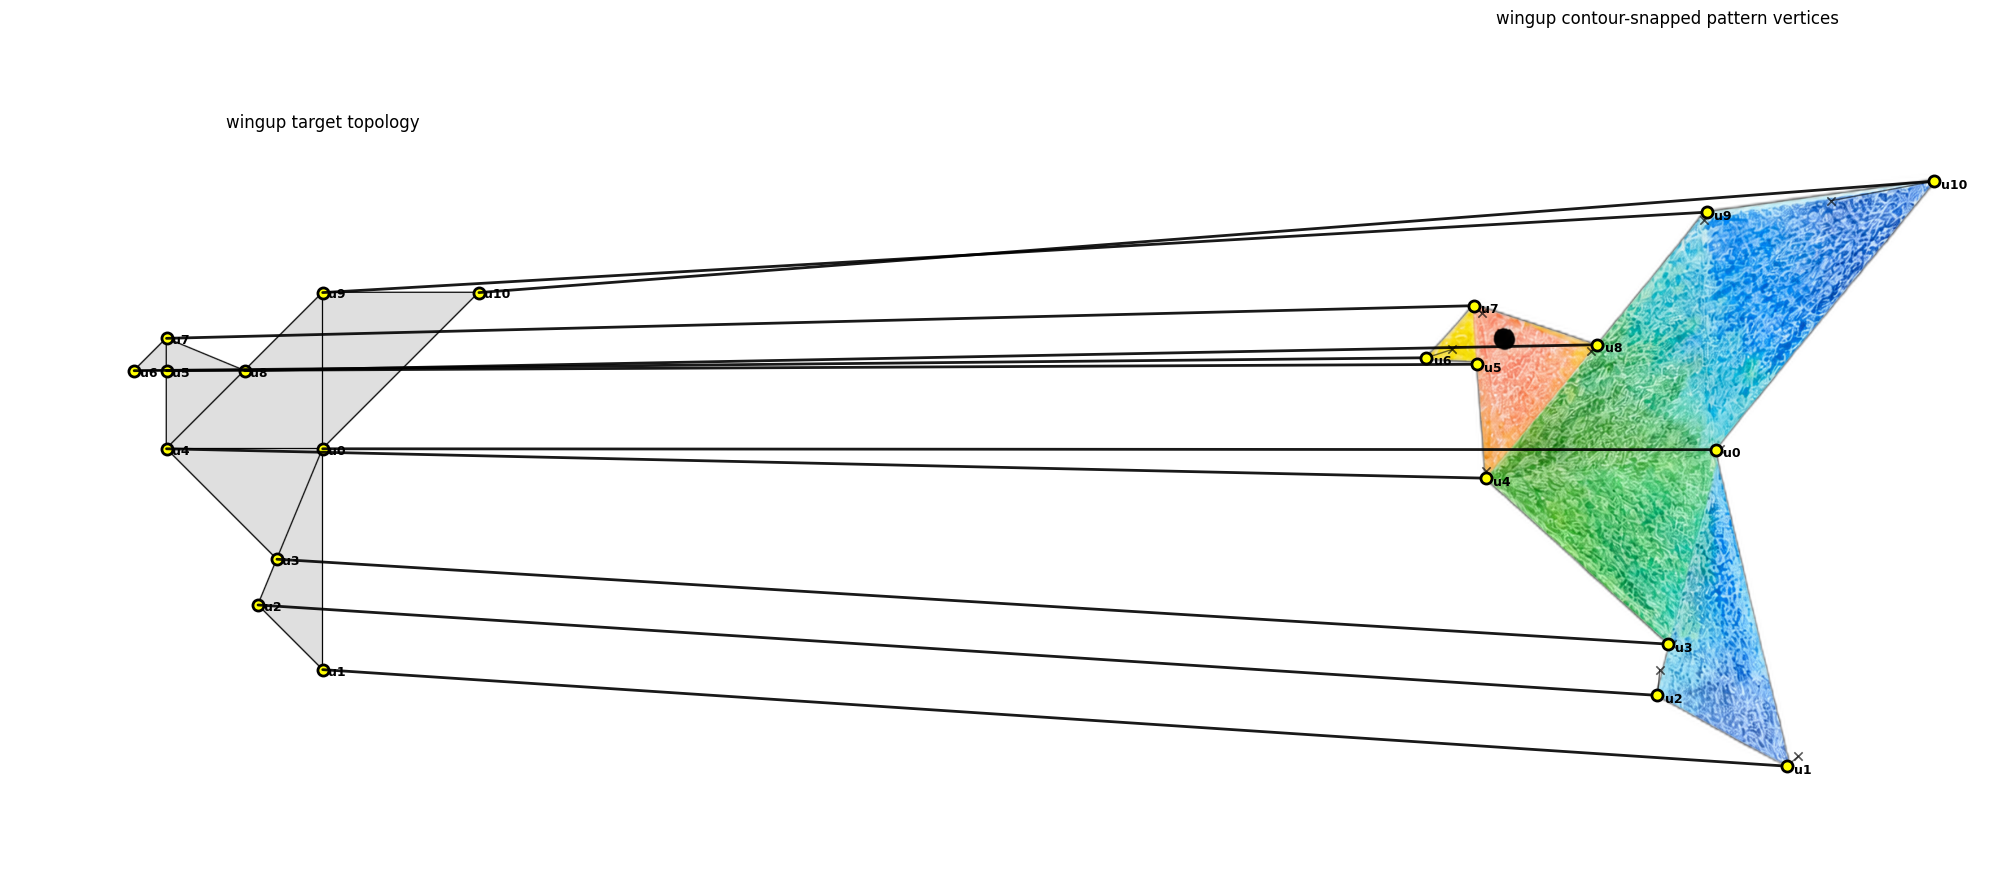

wingdown: snapped 11/11 matched pattern vertices (10 to vertices, 1 to contour fallback) using 10 contour vertices


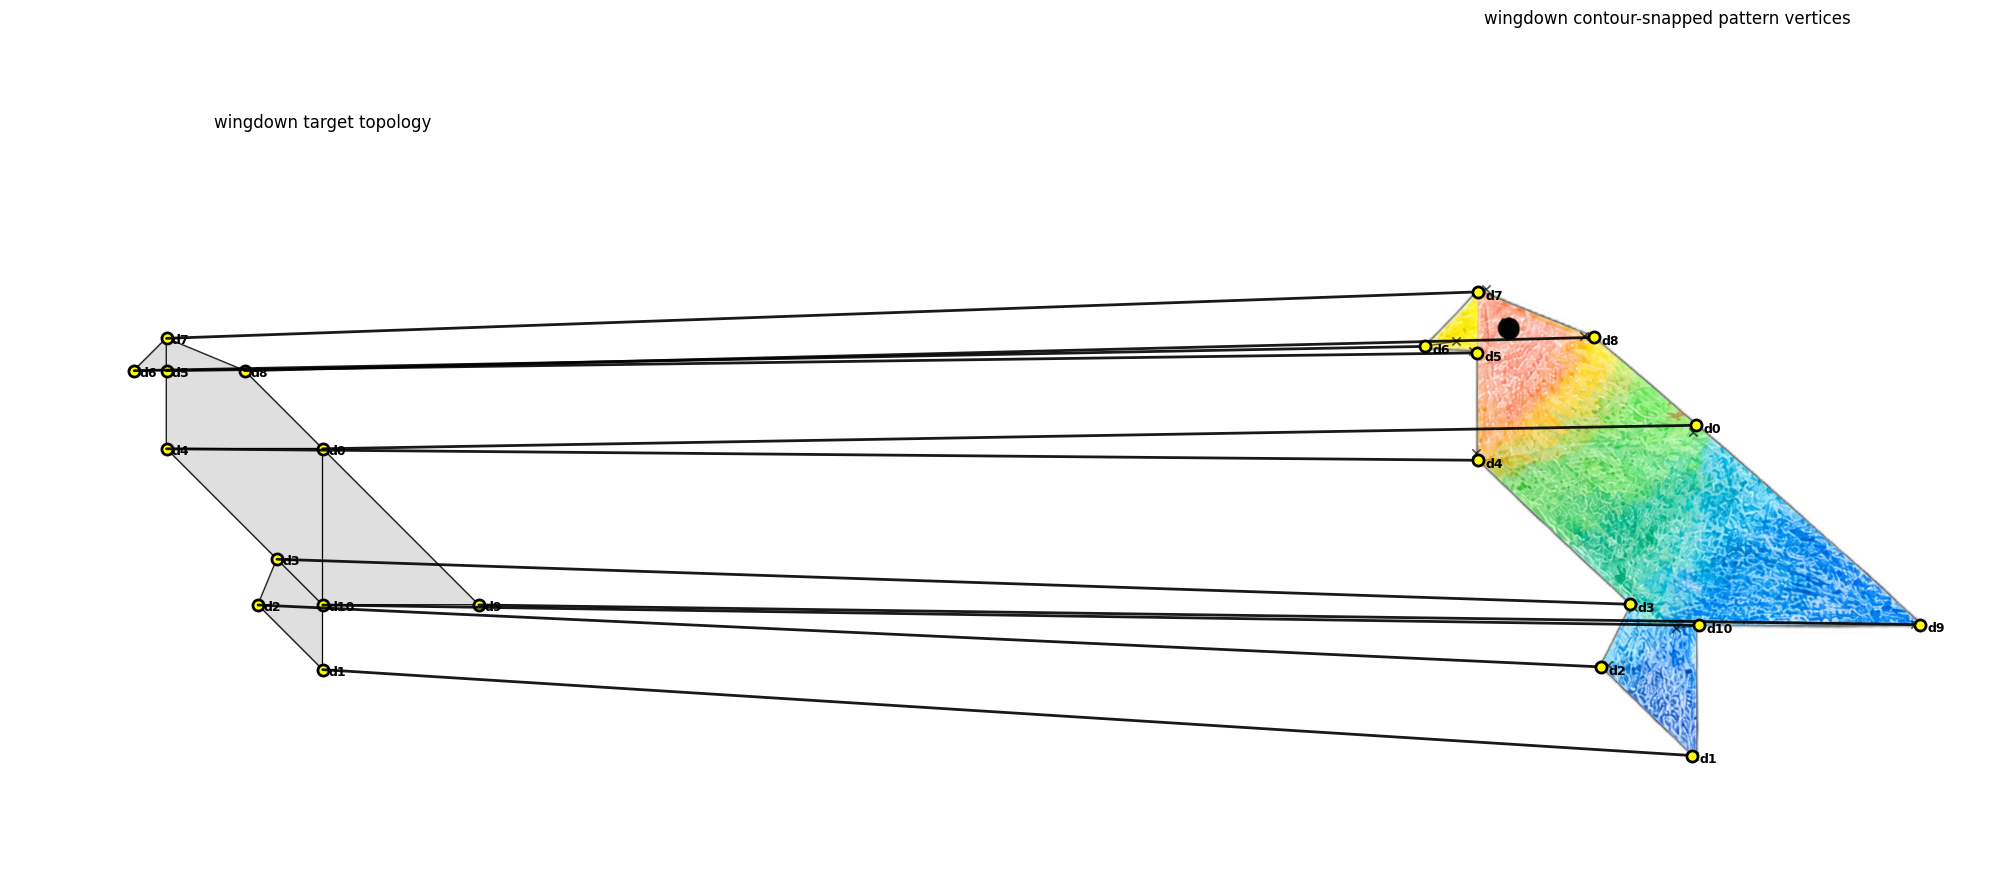

In [14]:
import copy
import cv2

CONTOUR_ALPHA_THRESHOLD = globals().get("CONTOUR_ALPHA_THRESHOLD", 0.5)
CONTOUR_APPROXIMATION_EPSILON_RATIO = globals().get("CONTOUR_APPROXIMATION_EPSILON_RATIO", 0.012)
CONTOUR_MIN_AREA = globals().get("CONTOUR_MIN_AREA", 100.0)
pattern_paths = globals().get(
    "pattern_paths",
    {
        "wingup": generated_wingup_path,
        "wingdown": generated_wingdown_path,
    },
)
warped_paths = {
    "wingup": warped_wingpup_path,
    "wingdown": warped_wingdown_path,
}


def get_item_alpha(item: dict, image_path: Path | None = None) -> np.ndarray:
    if "alpha" in item:
        return item["alpha"]

    if image_path is None:
        return item["mask"].astype(np.float32)

    return np.array(Image.open(image_path).convert("RGBA").getchannel("A"))


def contour_mask_from_alpha(alpha_mask: np.ndarray | torch.Tensor) -> np.ndarray:
    if isinstance(alpha_mask, torch.Tensor):
        alpha_np = alpha_mask.detach().cpu().numpy()
    else:
        alpha_np = np.asarray(alpha_mask)

    if alpha_np.dtype == np.bool_:
        mask_np = alpha_np
    elif np.issubdtype(alpha_np.dtype, np.integer):
        mask_np = alpha_np > int(round(CONTOUR_ALPHA_THRESHOLD * 255))
    else:
        mask_np = alpha_np > CONTOUR_ALPHA_THRESHOLD

    return mask_np.astype(np.uint8) * 255


def extract_contours_xy(
    alpha_mask: np.ndarray | torch.Tensor,
    min_contour_area: float = CONTOUR_MIN_AREA,
) -> list[np.ndarray]:
    mask = contour_mask_from_alpha(alpha_mask)
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    return [
        contour.reshape(-1, 2).astype(float)
        for contour in contours
        if cv2.contourArea(contour) >= min_contour_area
    ]


def extract_contour_points_xy(
    alpha_mask: np.ndarray | torch.Tensor,
    min_contour_area: float = CONTOUR_MIN_AREA,
) -> np.ndarray:
    mask = contour_mask_from_alpha(alpha_mask)
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    contour_points = [
        contour.reshape(-1, 2).astype(float)
        for contour in contours
        if cv2.contourArea(contour) >= min_contour_area
    ]
    if not contour_points:
        return np.empty((0, 2), dtype=float)

    return np.vstack(contour_points)


def approximate_contour_vertices_xy(
    contour_xy: np.ndarray,
    approximation_epsilon_ratio: float = CONTOUR_APPROXIMATION_EPSILON_RATIO,
) -> np.ndarray:
    if len(contour_xy) == 0:
        return np.empty((0, 2), dtype=float)

    contour = contour_xy.reshape(-1, 1, 2).astype(np.float32)
    epsilon = approximation_epsilon_ratio * cv2.arcLength(contour, closed=True)
    approximated = cv2.approxPolyDP(contour, epsilon, closed=True)
    return approximated.reshape(-1, 2).astype(float)


def extract_contour_vertices_xy(
    alpha_mask: np.ndarray | torch.Tensor,
    approximation_epsilon_ratio: float = CONTOUR_APPROXIMATION_EPSILON_RATIO,
    min_contour_area: float = CONTOUR_MIN_AREA,
) -> np.ndarray:
    vertices = []
    for contour_xy in extract_contours_xy(alpha_mask, min_contour_area=min_contour_area):
        vertices.extend(
            approximate_contour_vertices_xy(
                contour_xy,
                approximation_epsilon_ratio=approximation_epsilon_ratio,
            )
        )

    if not vertices:
        return np.empty((0, 2), dtype=float)

    vertices_xy = np.array(vertices, dtype=float)
    return np.unique(np.round(vertices_xy, 2), axis=0)

def snap_points_to_nearest_vertices(
    points_xy: np.ndarray,
    vertices_xy: np.ndarray,
    fallback_contour_xy: np.ndarray | None = None,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    if len(points_xy) == 0:
        empty_mask = np.zeros(0, dtype=bool)
        return points_xy.copy(), np.empty(0, dtype=float), empty_mask, empty_mask

    snapped_points_xy = points_xy.copy()
    snapped_mask = np.zeros(len(points_xy), dtype=bool)
    vertex_snapped_mask = np.zeros(len(points_xy), dtype=bool)
    assigned_distances = np.full(len(points_xy), np.nan, dtype=float)

    if len(vertices_xy) > 0:
        deltas = points_xy[:, None, :] - vertices_xy[None, :, :]
        distances = np.linalg.norm(deltas, axis=2)
        vertex_preferences = np.argsort(distances, axis=1)
        next_preference_indices = np.zeros(len(points_xy), dtype=int)
        assigned_point_by_vertex: dict[int, int] = {}
        assigned_vertex_by_point = np.full(len(points_xy), -1, dtype=int)
        pending_point_indices = list(range(len(points_xy)))

        while pending_point_indices:
            point_index = pending_point_indices.pop(0)
            if next_preference_indices[point_index] >= len(vertices_xy):
                continue

            vertex_index = int(vertex_preferences[point_index, next_preference_indices[point_index]])
            next_preference_indices[point_index] += 1
            current_point_index = assigned_point_by_vertex.get(vertex_index)

            if current_point_index is None:
                assigned_point_by_vertex[vertex_index] = point_index
                assigned_vertex_by_point[point_index] = vertex_index
                continue

            point_distance = distances[point_index, vertex_index]
            current_distance = distances[current_point_index, vertex_index]
            point_is_closer = point_distance < current_distance
            point_wins_tie = point_distance == current_distance and point_index < current_point_index

            if point_is_closer or point_wins_tie:
                assigned_point_by_vertex[vertex_index] = point_index
                assigned_vertex_by_point[point_index] = vertex_index
                assigned_vertex_by_point[current_point_index] = -1
                pending_point_indices.append(current_point_index)
            else:
                pending_point_indices.append(point_index)

        vertex_snapped_mask = assigned_vertex_by_point >= 0
        if vertex_snapped_mask.any():
            assigned_point_indices = np.where(vertex_snapped_mask)[0]
            assigned_vertex_indices = assigned_vertex_by_point[assigned_point_indices]
            snapped_points_xy[assigned_point_indices] = vertices_xy[assigned_vertex_indices]
            assigned_distances[assigned_point_indices] = distances[assigned_point_indices, assigned_vertex_indices]
            snapped_mask[assigned_point_indices] = True

    fallback_mask = ~snapped_mask
    if fallback_contour_xy is not None and len(fallback_contour_xy) > 0 and fallback_mask.any():
        fallback_point_indices = np.where(fallback_mask)[0]
        fallback_deltas = points_xy[fallback_point_indices, None, :] - fallback_contour_xy[None, :, :]
        fallback_distances = np.linalg.norm(fallback_deltas, axis=2)
        nearest_fallback_indices = np.argmin(fallback_distances, axis=1)

        snapped_points_xy[fallback_point_indices] = fallback_contour_xy[nearest_fallback_indices]
        assigned_distances[fallback_point_indices] = fallback_distances[
            np.arange(len(fallback_point_indices)),
            nearest_fallback_indices,
        ]
        snapped_mask[fallback_point_indices] = True

    return snapped_points_xy, assigned_distances, snapped_mask, vertex_snapped_mask


raw_matched_vertices_by_pose = copy.deepcopy(matched_vertices_by_pose)
contour_snapped_vertices_by_pose = copy.deepcopy(matched_vertices_by_pose)
contour_snap_results_by_pose = {}

for pose_name, matched_vertices in raw_matched_vertices_by_pose.items():
    pair = pairs[pose_name]
    target_image = pair["target"]["image"]
    pattern_image = pair["pattern"]["image"]
    pattern_alpha = get_item_alpha(pair["pattern"], pattern_paths[pose_name])

    valid_vertex_names = [
        vertex_name
        for vertex_name, vertex in matched_vertices.items()
        if vertex["pattern_xy"] is not None
    ]
    raw_pattern_points_xy = np.array(
        [matched_vertices[vertex_name]["pattern_xy"] for vertex_name in valid_vertex_names],
        dtype=float,
    )

    pattern_contour_vertices_xy = extract_contour_vertices_xy(pattern_alpha)
    pattern_contour_points_xy = extract_contour_points_xy(pattern_alpha)
    (
        snapped_pattern_points_xy,
        contour_snap_distances,
        contour_snapped_mask,
        contour_vertex_snapped_mask,
    ) = snap_points_to_nearest_vertices(
        raw_pattern_points_xy,
        pattern_contour_vertices_xy,
        fallback_contour_xy=pattern_contour_points_xy,
    )

    for vertex_name, snapped_xy in zip(valid_vertex_names, snapped_pattern_points_xy):
        contour_snapped_vertices_by_pose[pose_name][vertex_name]["pattern_xy"] = snapped_xy.round(3).tolist()

    contour_snap_results_by_pose[pose_name] = {
        "contour_vertices_xy": pattern_contour_vertices_xy,
        "contour_points_xy": pattern_contour_points_xy,
        "raw_pattern_points_xy": raw_pattern_points_xy,
        "snapped_pattern_points_xy": snapped_pattern_points_xy,
        "distances": contour_snap_distances,
        "snapped_mask": contour_snapped_mask,
        "vertex_snapped_mask": contour_vertex_snapped_mask,
        "vertex_names": valid_vertex_names,
    }

    print(
        f"{pose_name}: snapped {contour_snapped_mask.sum()}/{len(contour_snapped_mask)} matched pattern vertices "
        f"({contour_vertex_snapped_mask.sum()} to vertices, "
        f"{(contour_snapped_mask & ~contour_vertex_snapped_mask).sum()} to contour fallback) "
        f"using {len(pattern_contour_vertices_xy)} contour vertices"
    )

    fig = plt.figure(figsize=(20, 10))

    ax1 = fig.add_subplot(121)
    ax1.imshow(target_image)
    ax1.set_title(f"{pose_name} target topology")
    ax1.set_axis_off()

    ax2 = fig.add_subplot(122)
    ax2.imshow(pattern_image)
    ax2.set_title(f"{pose_name} contour-snapped pattern vertices")
    ax2.set_axis_off()

    if len(pattern_contour_vertices_xy) > 0:
        ax2.scatter(
            pattern_contour_vertices_xy[:, 0],
            pattern_contour_vertices_xy[:, 1],
            s=28,
            marker="D",
            facecolors="none",
            edgecolors="white",
            linewidths=0.9,
            alpha=0.75,
            zorder=2,
        )

    for vertex_name, vertex in matched_vertices.items():
        target_x, target_y = vertex["target_xy"]

        ax1.scatter(
            target_x,
            target_y,
            s=64,
            c="yellow",
            edgecolors="black",
            linewidths=2.0,
            zorder=3,
        )

        ax1.text(
            target_x + 9,
            target_y + 9,
            vertex_name,
            color="black",
            fontsize=9,
            fontweight="bold",
            zorder=4,
        )

        if vertex["pattern_xy"] is None:
            continue

        snapped_vertex = contour_snapped_vertices_by_pose[pose_name][vertex_name]
        raw_pattern_x, raw_pattern_y = vertex["pattern_xy"]
        pattern_x, pattern_y = snapped_vertex["pattern_xy"]
        result_index = valid_vertex_names.index(vertex_name)
        was_snapped = contour_snapped_mask[result_index]

        ax2.scatter(
            raw_pattern_x,
            raw_pattern_y,
            s=36,
            marker="x",
            c="black",
            linewidths=1.2,
            alpha=0.65,
            zorder=3,
        )

        if was_snapped:
            ax2.plot(
                [raw_pattern_x, pattern_x],
                [raw_pattern_y, pattern_y],
                color="black",
                linewidth=1.0,
                alpha=0.55,
                zorder=3,
            )

        ax2.scatter(
            pattern_x,
            pattern_y,
            s=64,
            c="yellow",
            edgecolors="black",
            linewidths=2.0,
            zorder=4,
        )

        ax2.text(
            pattern_x + 9,
            pattern_y + 9,
            vertex_name,
            color="black",
            fontsize=9,
            fontweight="bold",
            zorder=5,
        )

        con = ConnectionPatch(
            xyA=(target_x, target_y),
            xyB=(pattern_x, pattern_y),
            coordsA="data",
            coordsB="data",
            axesA=ax1,
            axesB=ax2,
            color="black",
            linewidth=2.0,
            alpha=0.9,
        )
        ax2.add_artist(con)

    fig.tight_layout()
    plt.show()

# Use contour-snapped vertices in later cells while keeping raw_matched_vertices_by_pose available.
matched_vertices_by_pose = contour_snapped_vertices_by_pose


## Warp Pattern

wingup: warped 6/6 faces -> C:\Users\morph\GitHub\origami-texturing\data\processed\warped-wingup.png


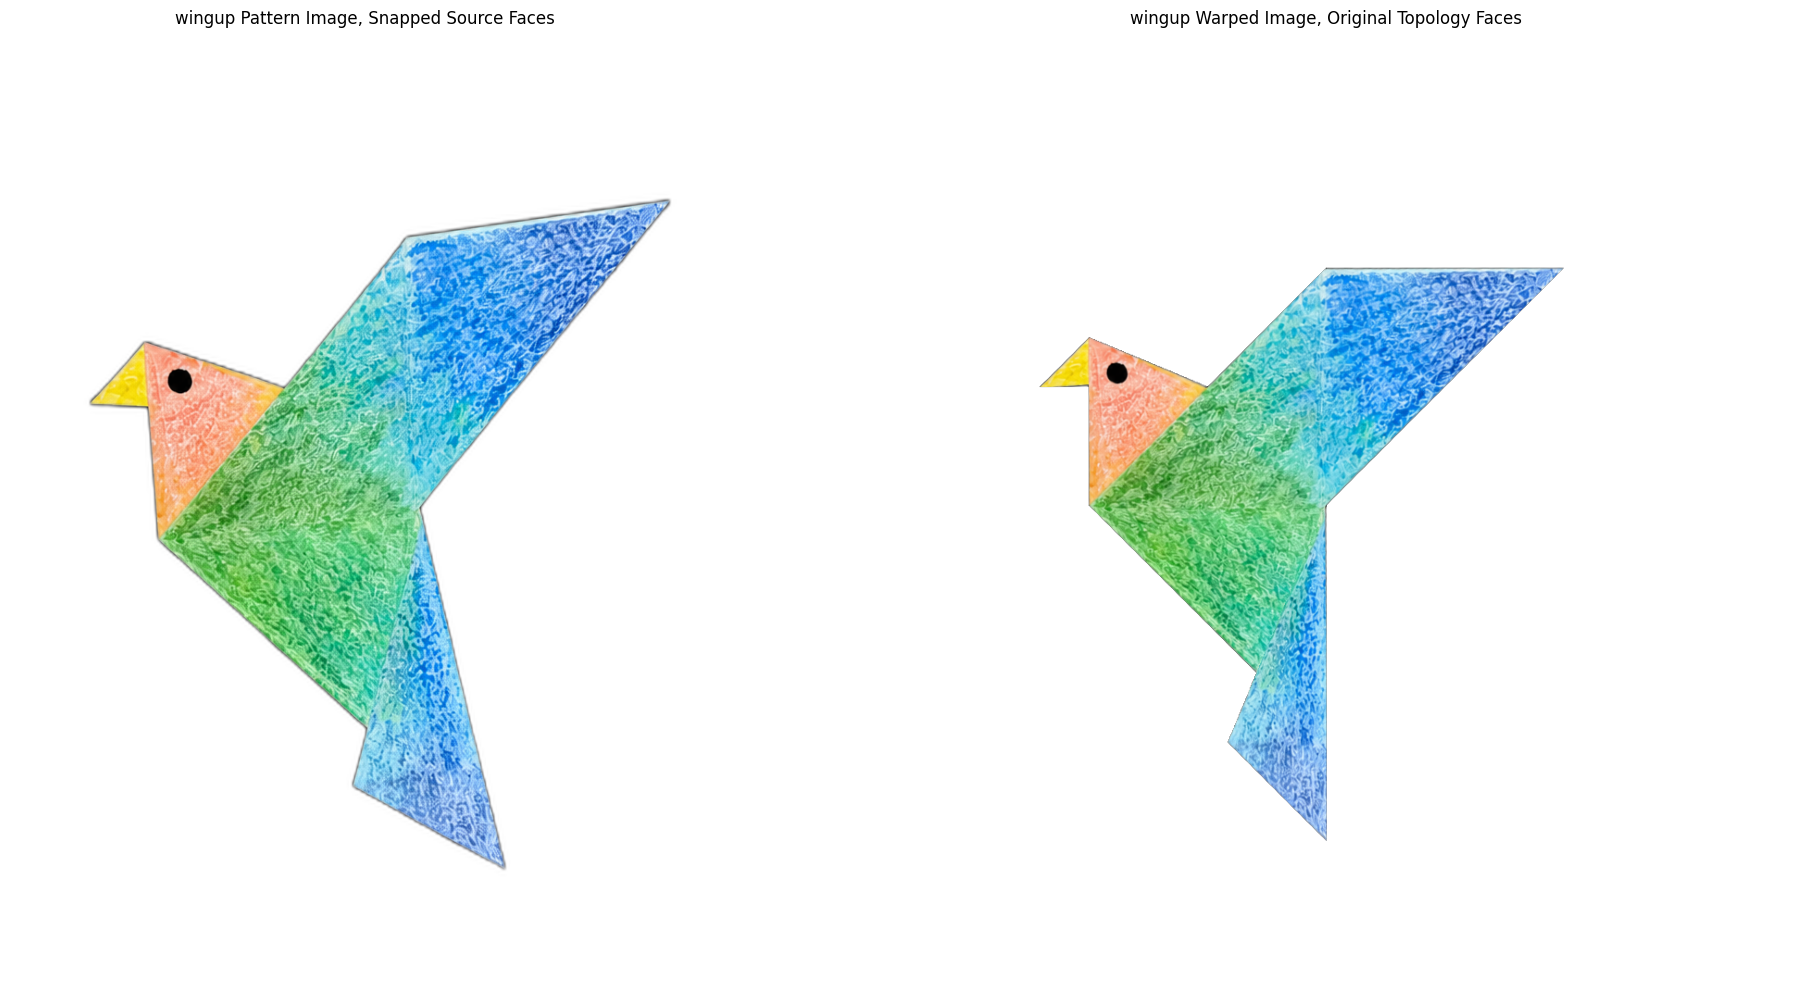

wingdown: warped 5/5 faces -> C:\Users\morph\GitHub\origami-texturing\data\processed\warped-wingdown.png


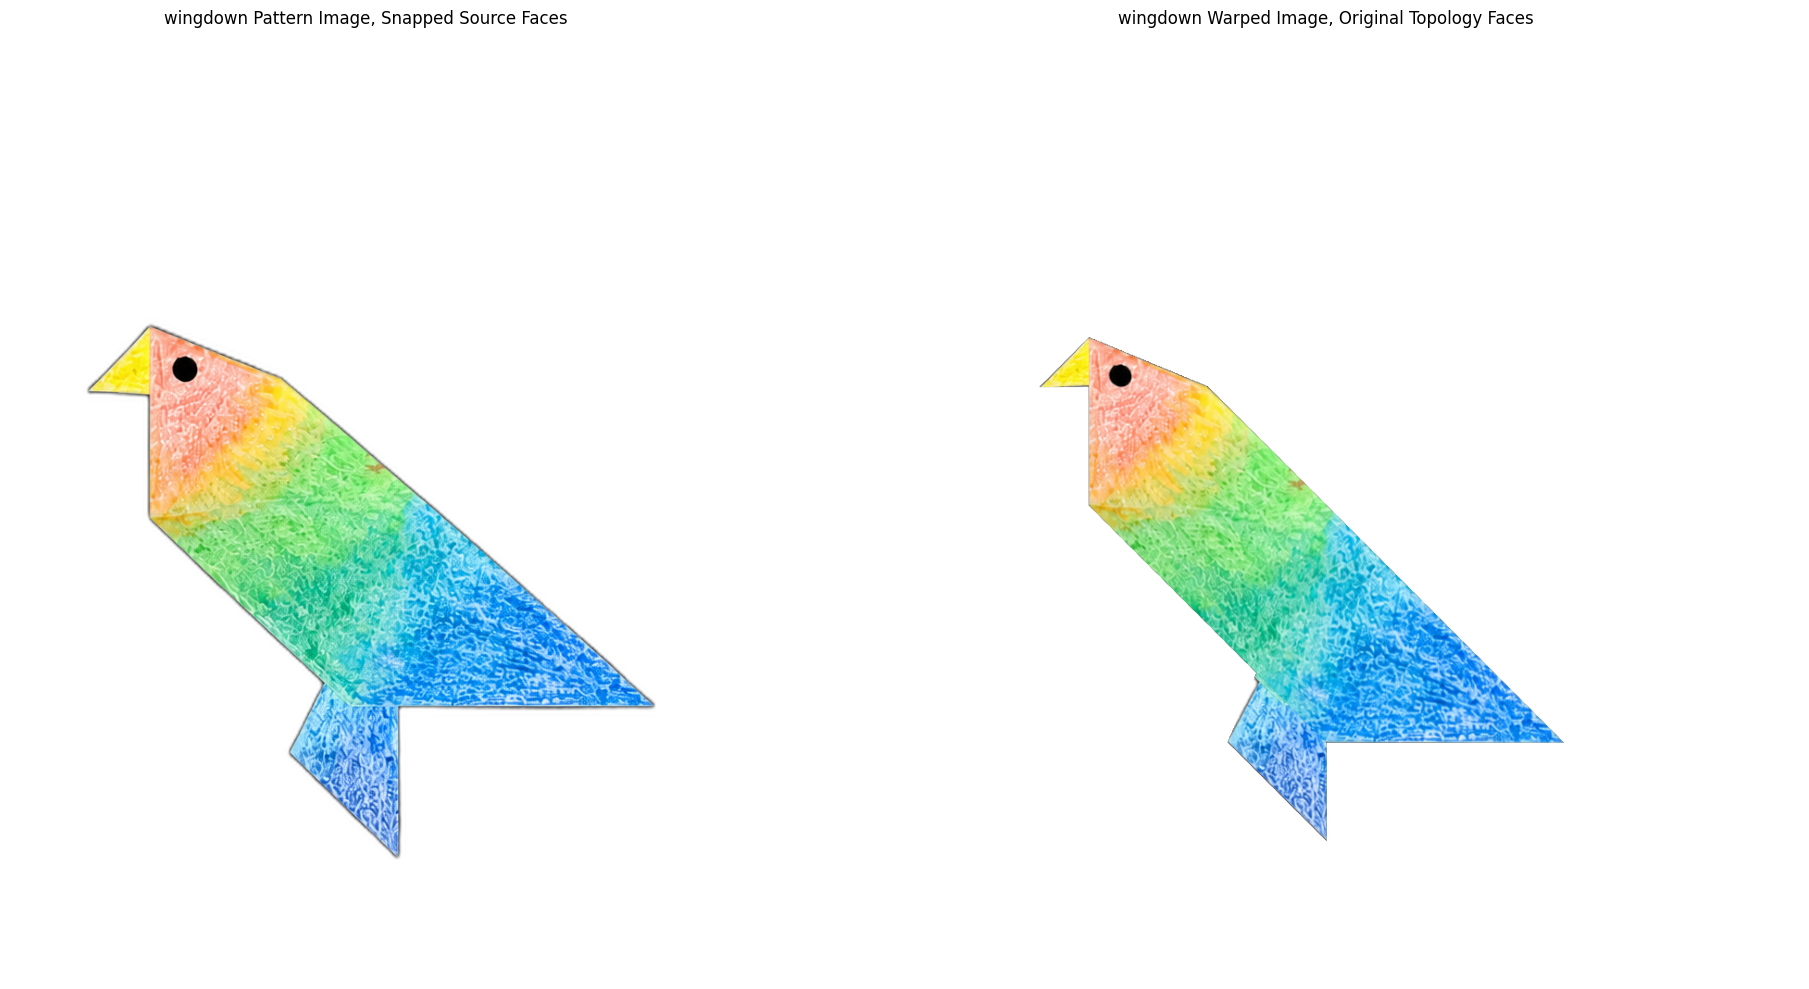

wingup: preview -> C:\Users\morph\GitHub\origami-texturing\outputs\preview.png


In [15]:
import cv2

pattern_paths = globals().get(
    "pattern_paths",
    {
        "wingup": generated_wingup_path,
        "wingdown": generated_wingdown_path,
    },
)


def load_rgba_array(path: Path) -> np.ndarray:
    return np.array(Image.open(path).convert("RGBA"))


def affine_warp_triangle_rgba(
    source_rgba: np.ndarray,
    output_size: tuple[int, int],
    source_triangle_xy: np.ndarray,
    target_triangle_xy: np.ndarray,
) -> tuple[np.ndarray, np.ndarray]:
    output_width, output_height = output_size
    source_triangle = source_triangle_xy.astype(np.float32)
    target_triangle = target_triangle_xy.astype(np.float32)

    transform = cv2.getAffineTransform(source_triangle, target_triangle)
    warped_rgba = cv2.warpAffine(
        source_rgba,
        transform,
        (output_width, output_height),
        flags=cv2.INTER_LINEAR,
        borderMode=cv2.BORDER_CONSTANT,
        borderValue=(0, 0, 0, 0),
    )

    triangle_mask = np.zeros((output_height, output_width), dtype=np.uint8)
    cv2.fillConvexPoly(
        triangle_mask,
        np.round(target_triangle).astype(np.int32),
        255,
    )
    return warped_rgba, triangle_mask


def alpha_composite_rgba(base_rgba: np.ndarray, overlay_rgba: np.ndarray) -> np.ndarray:
    base = base_rgba.astype(np.float32) / 255.0
    overlay = overlay_rgba.astype(np.float32) / 255.0

    overlay_alpha = overlay[..., 3:4]
    base_alpha = base[..., 3:4]
    output_alpha = overlay_alpha + base_alpha * (1.0 - overlay_alpha)

    output_rgb = np.zeros_like(base[..., :3])
    nonzero_alpha = output_alpha[..., 0] > 1e-6
    output_rgb[nonzero_alpha] = (
        overlay[..., :3][nonzero_alpha] * overlay_alpha[..., 0:1][nonzero_alpha]
        + base[..., :3][nonzero_alpha] * base_alpha[..., 0:1][nonzero_alpha] * (1.0 - overlay_alpha[..., 0:1][nonzero_alpha])
    ) / output_alpha[..., 0:1][nonzero_alpha]

    output = np.dstack([output_rgb, output_alpha[..., 0]])
    return np.clip(output * 255.0, 0, 255).astype(np.uint8)


def warp_pattern_to_topology(
    pattern_rgba: np.ndarray,
    target_size: tuple[int, int],
    topology: dict,
    matched_vertices: dict,
) -> tuple[np.ndarray, list[dict]]:
    output_width, output_height = target_size
    warped_output = np.zeros((output_height, output_width, 4), dtype=np.uint8)
    warped_faces = []

    for face_name, vertex_ids in topology["faces"].items():
        if len(vertex_ids) != 3:
            print(f"Skipping {face_name}: expected 3 vertices, got {len(vertex_ids)}")
            continue

        missing_vertices = [
            vertex_id
            for vertex_id in vertex_ids
            if vertex_id not in matched_vertices or matched_vertices[vertex_id]["pattern_xy"] is None
        ]
        if missing_vertices:
            print(f"Skipping {face_name}: missing pattern matches {missing_vertices}")
            continue

        source_triangle_xy = np.array(
            [matched_vertices[vertex_id]["pattern_xy"] for vertex_id in vertex_ids],
            dtype=np.float32,
        )
        target_triangle_xy = np.array(
            [topology["vertices"][vertex_id] for vertex_id in vertex_ids],
            dtype=np.float32,
        )

        if abs(cv2.contourArea(source_triangle_xy.reshape(-1, 1, 2))) < 1.0:
            print(f"Skipping {face_name}: degenerate source triangle")
            continue
        if abs(cv2.contourArea(target_triangle_xy.reshape(-1, 1, 2))) < 1.0:
            print(f"Skipping {face_name}: degenerate target triangle")
            continue

        warped_face_rgba, triangle_mask = affine_warp_triangle_rgba(
            pattern_rgba,
            target_size,
            source_triangle_xy,
            target_triangle_xy,
        )
        warped_face_rgba = warped_face_rgba.copy()
        warped_face_rgba[..., 3] = np.minimum(warped_face_rgba[..., 3], triangle_mask)
        warped_output = alpha_composite_rgba(warped_output, warped_face_rgba)

        warped_faces.append(
            {
                "face_name": face_name,
                "vertex_ids": vertex_ids,
                "source_triangle_xy": source_triangle_xy,
                "target_triangle_xy": target_triangle_xy,
            }
        )

    return warped_output, warped_faces


warped_patterns_by_pose = {}

for pose_name, matched_vertices in matched_vertices_by_pose.items():
    pair = pairs[pose_name]
    target_image = pair["target"]["image"]
    pattern_image = pair["pattern"]["image"]
    topology = json.loads(topology_paths[pose_name].read_text(encoding="utf-8"))
    pattern_rgba = load_rgba_array(pattern_paths[pose_name])

    warped_rgba, warped_faces = warp_pattern_to_topology(
        pattern_rgba,
        target_image.size,
        topology,
        matched_vertices,
    )

    output_path = warped_paths[pose_name]
    Image.fromarray(warped_rgba, mode="RGBA").save(output_path)

    warped_patterns_by_pose[pose_name] = {
        "image": Image.fromarray(warped_rgba, mode="RGBA"),
        "array": warped_rgba,
        "faces": warped_faces,
        "path": output_path,
    }

    print(f"{pose_name}: warped {len(warped_faces)}/{len(topology['faces'])} faces -> {output_path}")

    fig = plt.figure(figsize=(20, 10))

    ax1 = fig.add_subplot(121)
    ax1.imshow(pattern_image)
    ax1.set_title(f"{pose_name} Pattern Image, Snapped Source Faces")
    ax1.set_axis_off()

    ax2 = fig.add_subplot(122)
    ax2.imshow(warped_rgba)
    ax2.set_title(f"{pose_name} Warped Image, Original Topology Faces")
    ax2.set_xlim(0, target_image.width)
    ax2.set_ylim(target_image.height, 0)
    ax2.set_aspect("equal")
    ax2.set_axis_off()

    fig.tight_layout()
    plt.show()

preview_path = OUTPUT_DIR / "preview.png"
warped_patterns_by_pose["wingup"]["image"].save(preview_path)
print(f"wingup: preview -> {preview_path}")
